<a href="https://colab.research.google.com/github/rkvarmaa460-cpu/Upgrad/blob/main/Employee_Machine_Learning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the libraries
Data Understanding



In [ ]:
import numpy as np
import pandas as pd

Load the dataset

# Load the dataset

In [ ]:
df=pd.read_csv('/content/Employee_data.csv')

# Check the first few entries

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Stayed


In [ ]:
df['Remote Work']=df['Remote Work'].str.replace('Yes','1')
df['Remote Work']=df['Remote Work'].str.replace('No','0')

In [ ]:
df['Attrition']=df['Attrition'].str.replace('Stayed','0')
df['Attrition']=df['Attrition'].str.replace('Left','1')

In [ ]:
df.head(2)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,0,No,No,Excellent,Medium,0
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,0,No,No,Fair,Low,0


# Inspect the shape of the dataset

In [ ]:
df.shape

(74610, 24)

# Inspect the different columns in the dataset

In [ ]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size',
       'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='object')

Check Basic statistics

Check Summary of dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74610 entries, 0 to 74609
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 74610 non-null  int64  
 1   Age                         74610 non-null  int64  
 2   Gender                      74610 non-null  object 
 3   Years at Company            74610 non-null  int64  
 4   Job Role                    74610 non-null  object 
 5   Monthly Income              74610 non-null  int64  
 6   Work-Life Balance           74610 non-null  object 
 7   Job Satisfaction            74610 non-null  object 
 8   Performance Rating          74610 non-null  object 
 9   Number of Promotions        74610 non-null  int64  
 10  Overtime                    74610 non-null  object 
 11  Distance from Home          72698 non-null  float64
 12  Education Level             74610 non-null  object 
 13  Marital Status              746

Data Cleaning

Check the number of missing values
Check the missing values of each column

In [ ]:
df.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


# Check the percentage of missing values in each column

In [ ]:
missing_percentage=(df.isnull().sum()/len(df))*100
missing_percentage

,0
Employee ID,0.000000
Age,0.000000
Gender,0.000000
Years at Company,0.000000
Job Role,0.000000
Monthly Income,0.000000
Work-Life Balance,0.000000
Job Satisfaction,0.000000
Performance Rating,0.000000
Number of Promotions,0.000000


Handle rows with missing values in each column

In [ ]:
df=df.dropna(subset=['Distance from Home'])

In [ ]:
df=df.dropna(subset=['Company Tenure (In Months)'])

In [ ]:
df.shape

(70635, 24)

# Check the percentage of remaining data after missing values are removed

In [ ]:
missing_percent=(df.isnull().sum()/len(df))*100
missing_percent

,0
Employee ID,0.0
Age,0.0
Gender,0.0
Years at Company,0.0
Job Role,0.0
Monthly Income,0.0
Work-Life Balance,0.0
Job Satisfaction,0.0
Performance Rating,0.0
Number of Promotions,0.0


Identify and handle redundant values in categorical column

In [ ]:
# Write a function to display the categorical columns with their unique values and check for redundant values

In [ ]:
df.select_dtypes(include=['object']).nunique()

,0
Gender,2
Job Role,5
Work-Life Balance,4
Job Satisfaction,4
Performance Rating,4
Overtime,2
Education Level,5
Marital Status,3
Job Level,3
Company Size,3


In [ ]:
df.select_dtypes(include=['object']).duplicated().sum()

np.int64(2299)

In [ ]:
df['Gender'].duplicated().sum()

np.int64(70633)

Drop Redundant Column

In [ ]:
df.T.duplicated().sum()

np.int64(0)

Train Validate Splits

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size',
       'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='object')

# Put all the feature variables in X

# Put the target variable in y

In [ ]:
X=df[['Job Satisfaction','Performance Rating','Company Tenure (In Months)','Distance from Home']]
Y=df['Attrition']

Split the data

In [ ]:
# Split the data into 70% train data and 30% validation data

In [ ]:
# Step 1: Split into Train and Test (e.g., 70% Train, 30% Test)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

EDA on training data

Perform the univariant analysis for training data for all numerical column

select the numerical column

In [ ]:
df.select_dtypes(include=['int64','float64'])

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure (In Months)
0,8410,31,19,5390,2,22.0,0,89.0
1,64756,59,4,5534,3,21.0,3,21.0
2,30257,24,10,8159,0,11.0,3,74.0
3,65791,36,7,3989,1,27.0,2,50.0
4,65026,56,41,4821,0,71.0,0,68.0
...,...,...,...,...,...,...,...,...
74604,11030,57,12,8438,0,71.0,2,27.0
74605,13450,44,20,7578,2,25.0,3,52.0
74607,36968,28,3,9763,0,45.0,3,67.0
74608,24276,37,3,3644,2,16.0,4,16.0


Plot distribution of numerical column

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
numerical_columns=df.select_dtypes(include=['int64','float64']).columns

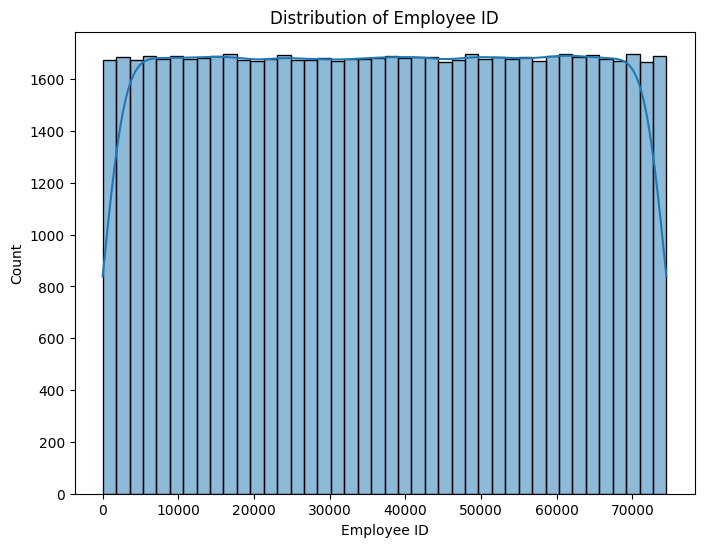

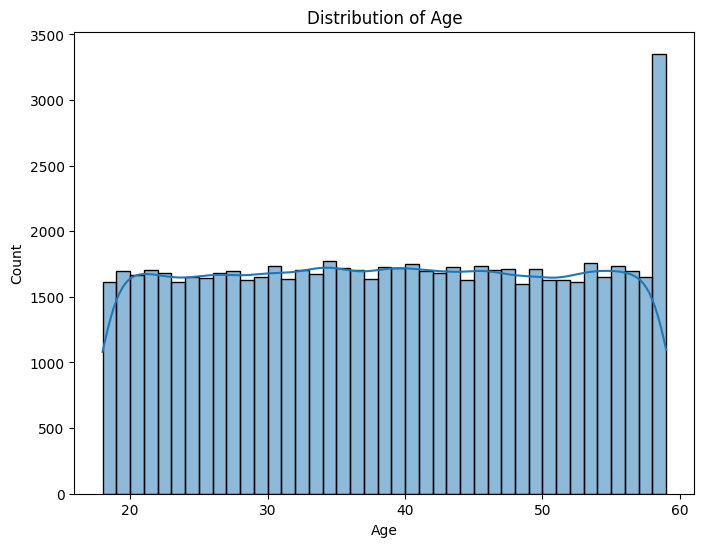

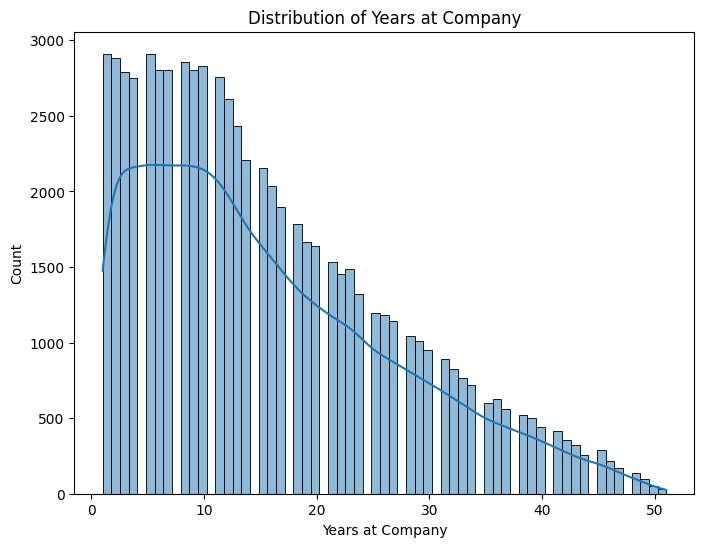

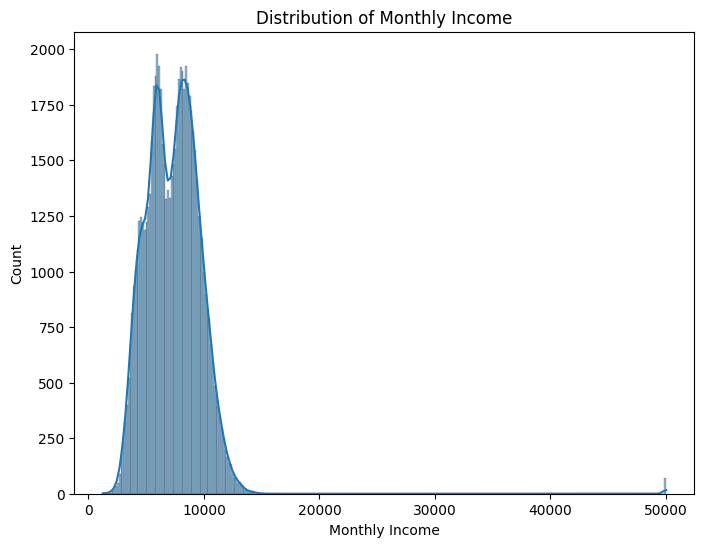

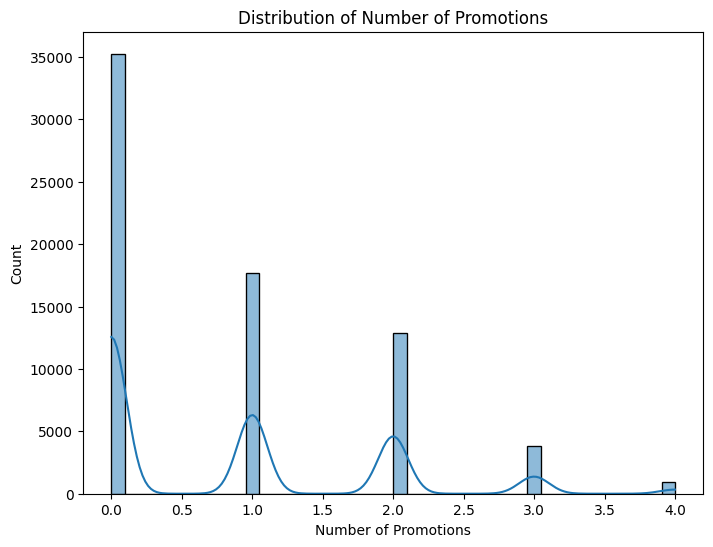

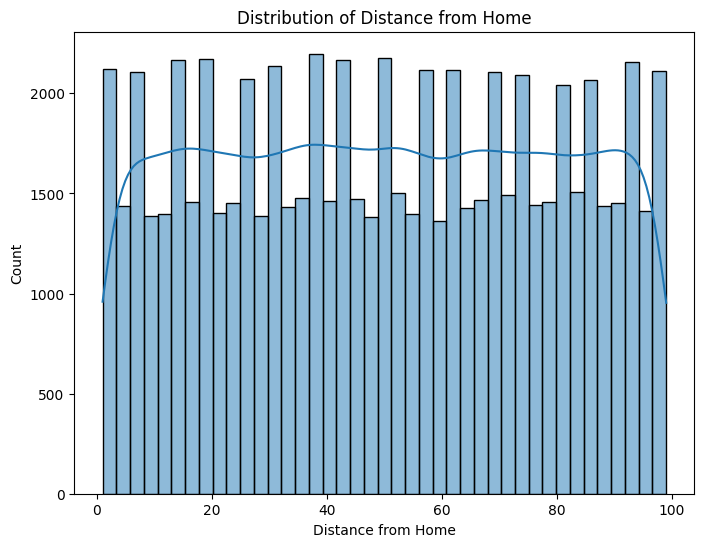

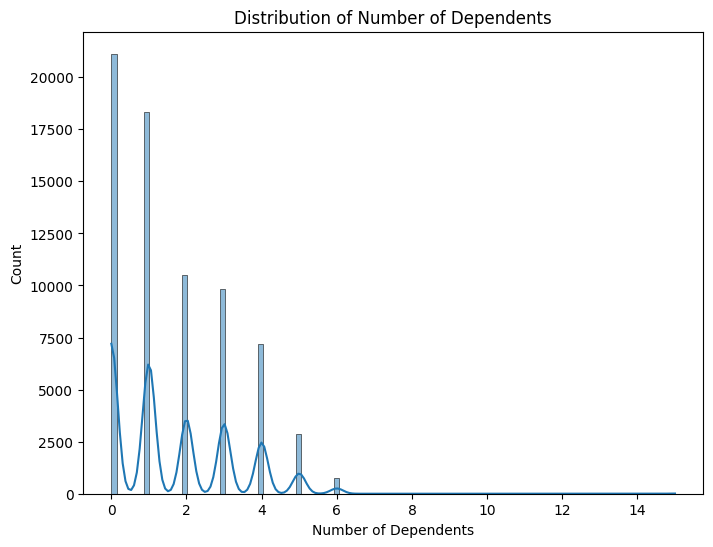

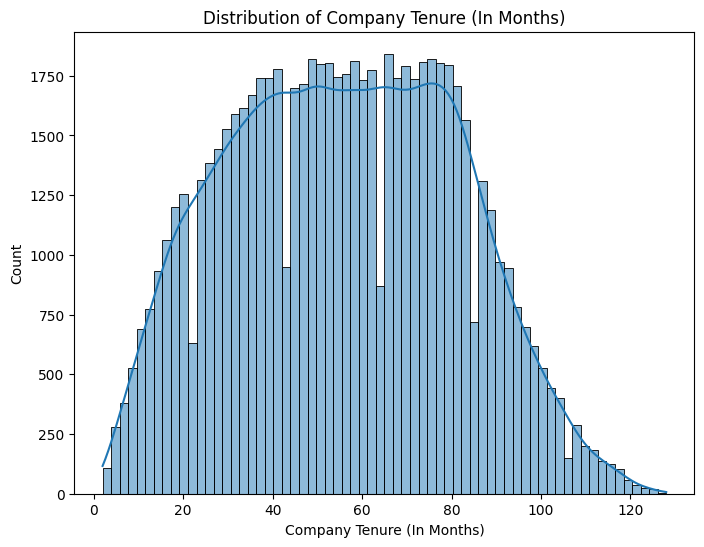

In [ ]:
for col in numerical_columns:
  plt.figure(figsize=(8,6))
  sns.histplot(df[col],kde=True)
  plt.title("Distribution of {}".format(col))
  plt.show()

Perform the correlation analysis for numerical column

In [ ]:
correlation_analysis=df[numerical_columns].corr()


# Plot Heatmap of the correlation matrix

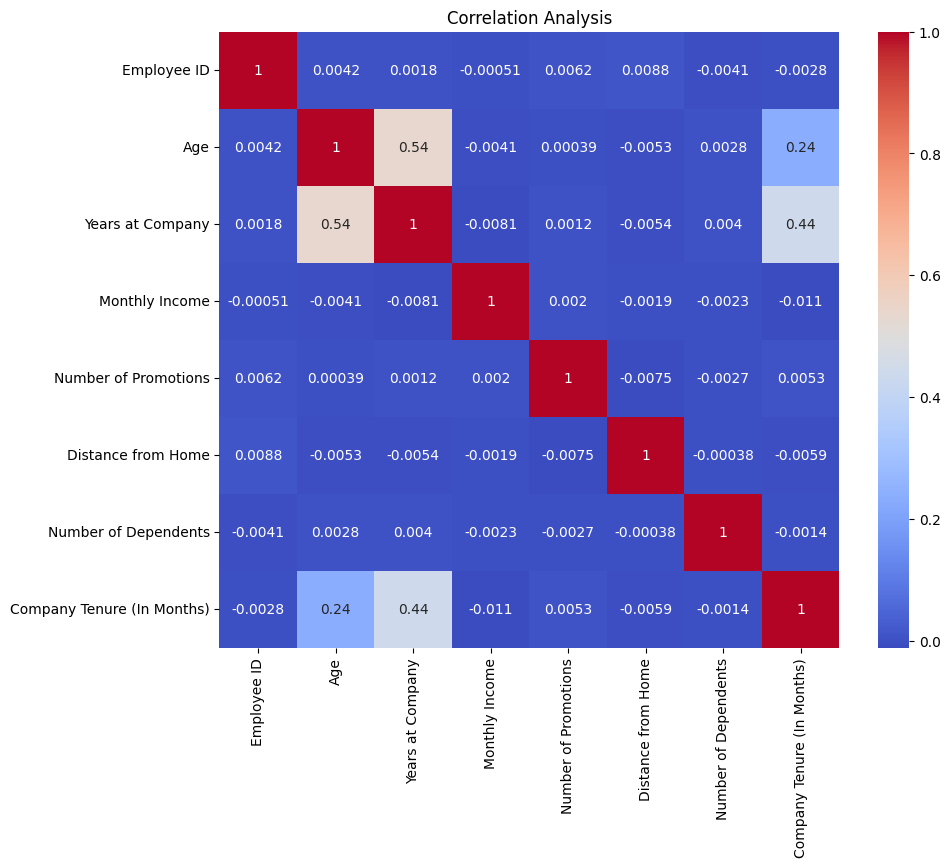

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_analysis,annot=True,cmap='coolwarm')
plt.title("Correlation Analysis")
plt.show()

Check the class balance

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
0,36810
1,33825


In [ ]:
##Perform the bivariant analysis

In [ ]:
df['Age'].corr(df['Years at Company'])

np.float64(0.5366616367087851)

In [ ]:
df['Age'].corr(df['Company Tenure (In Months)'])

np.float64(0.2362818117224386)

In [ ]:
df['Years at Company'].corr(df['Company Tenure (In Months)'])

np.float64(0.44266989466427475)

Perform the bivariant analysis on the categorical column

In [ ]:
categorial_col=df.select_dtypes(include=['object']).columns

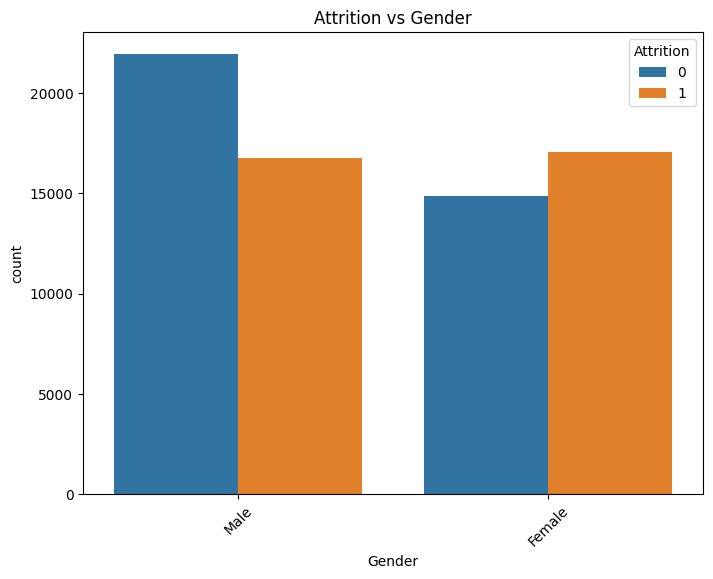

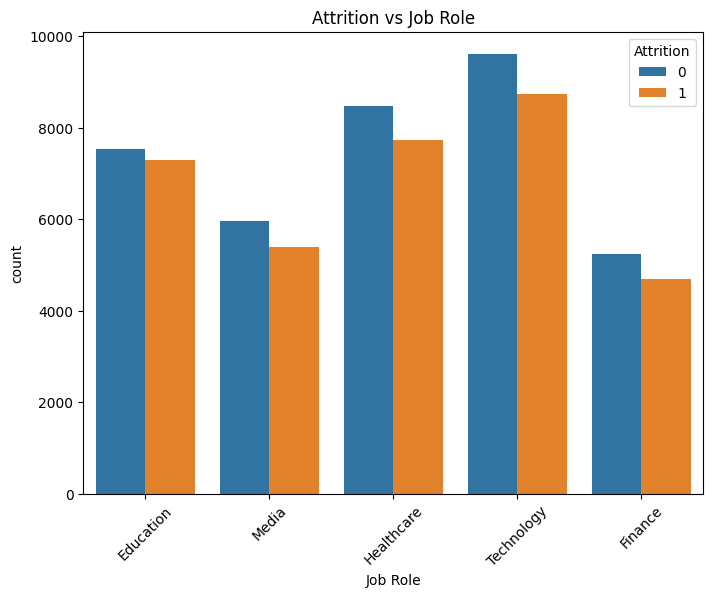

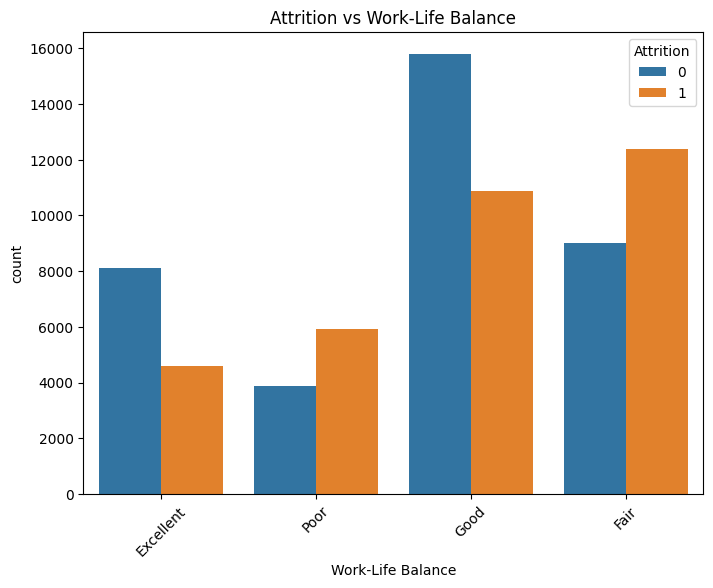

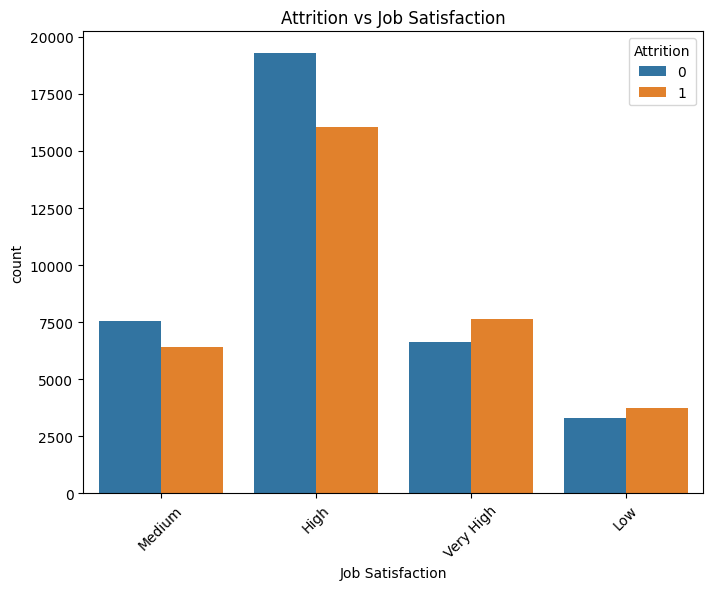

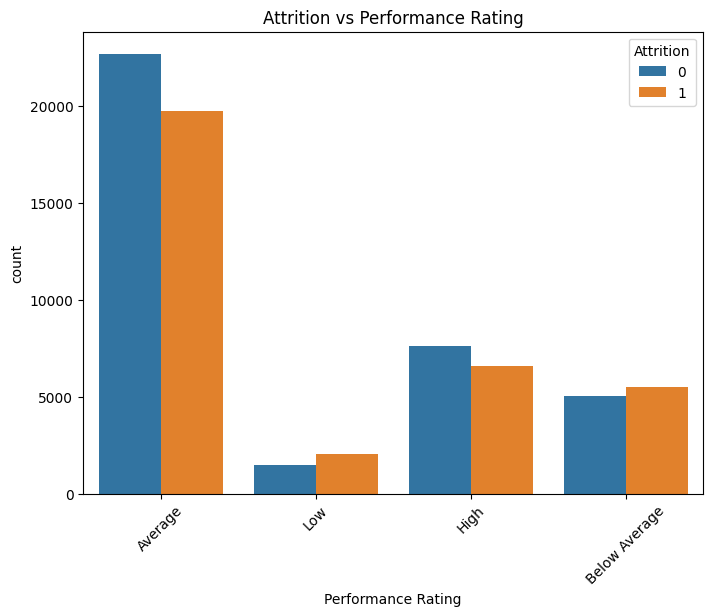

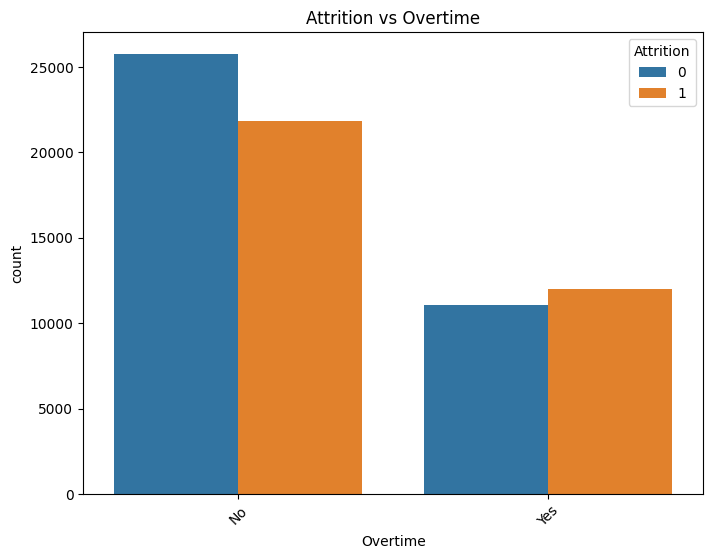

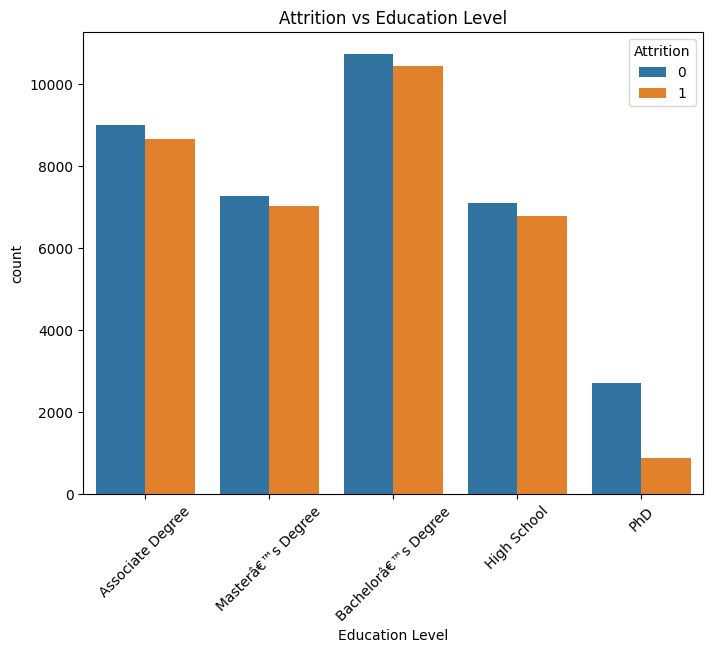

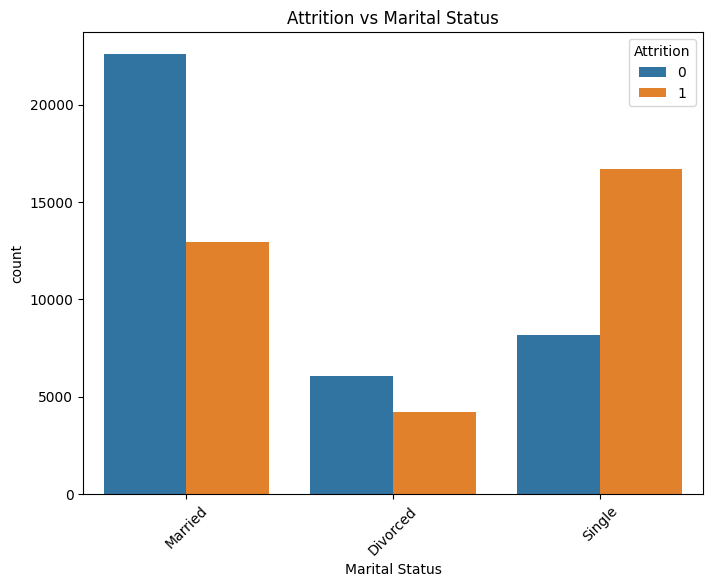

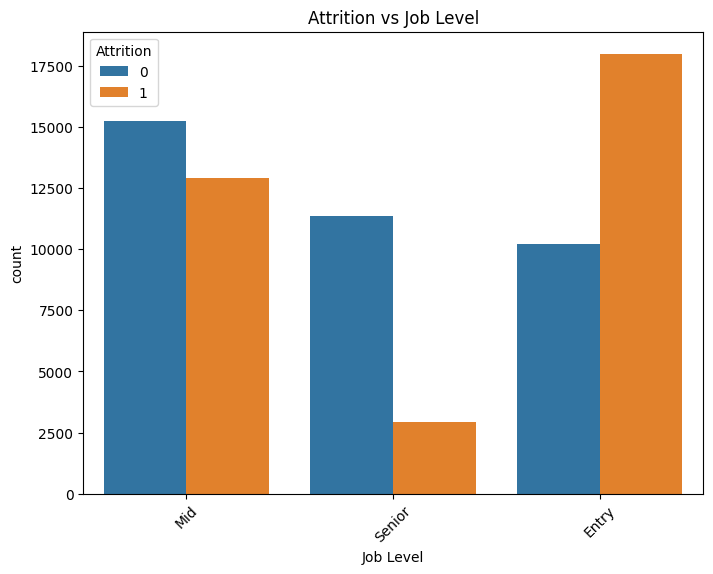

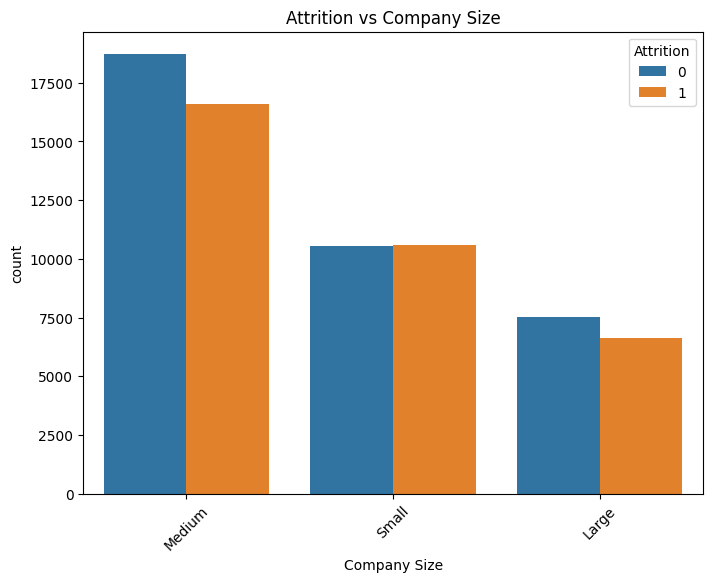

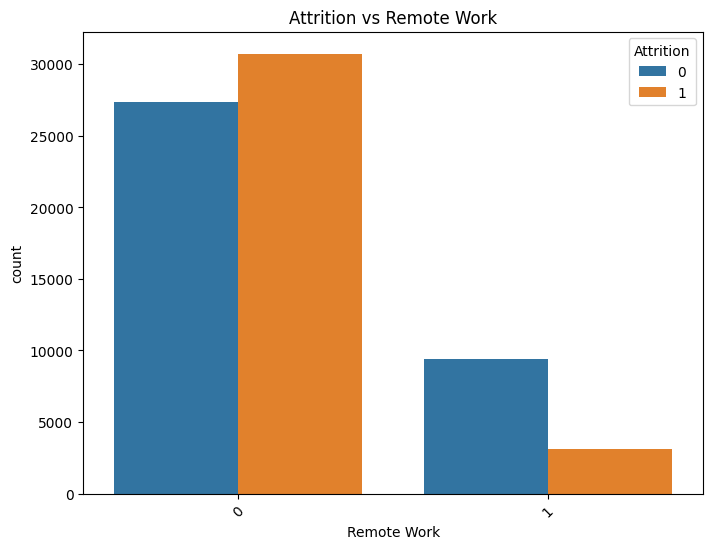

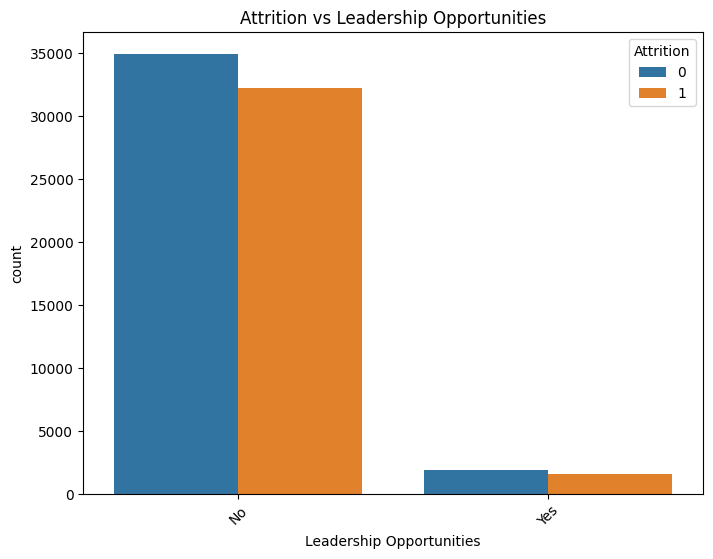

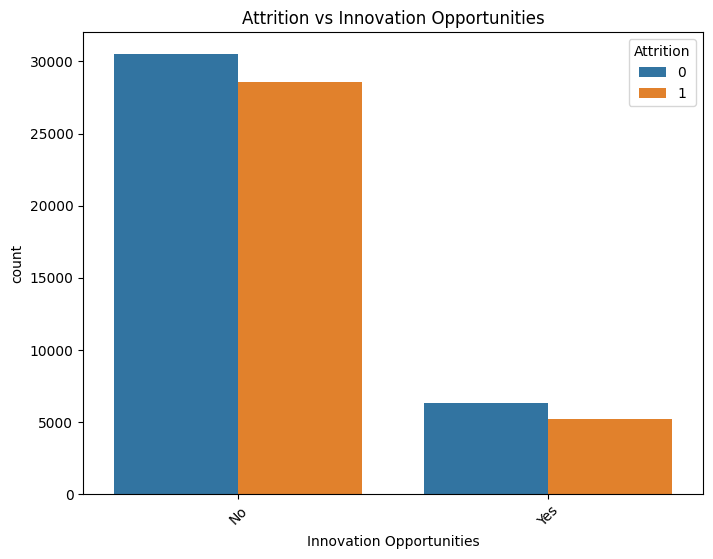

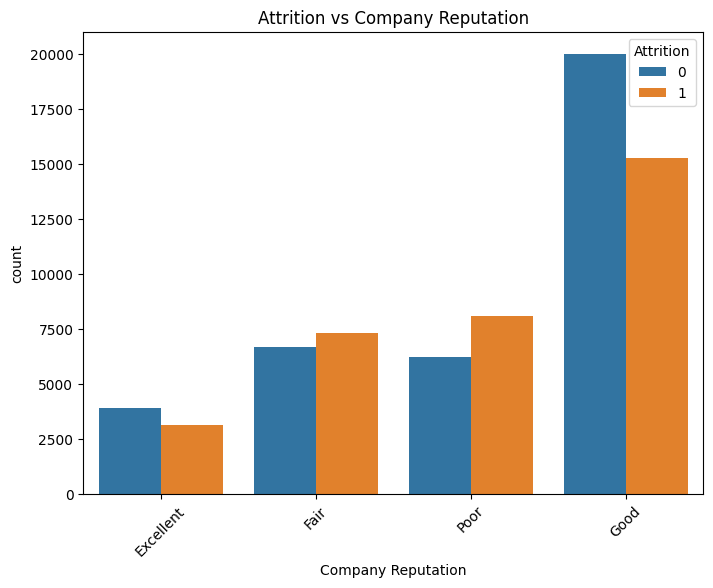

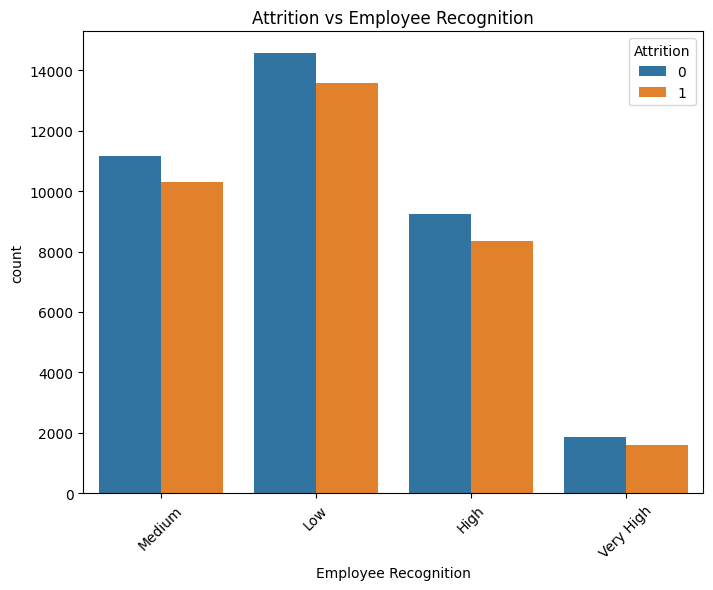

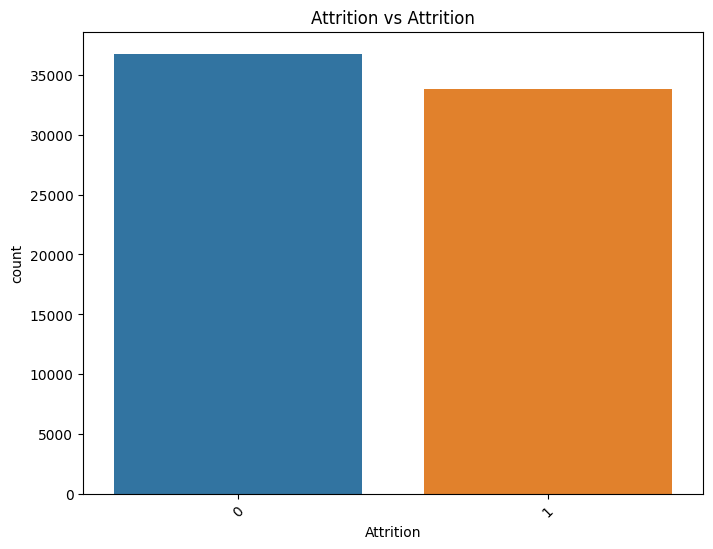

In [ ]:
for col in categorial_col:
  plt.figure(figsize=(8,6))
  sns.countplot(data=df,x=col,hue='Attrition')
  plt.title("Attrition vs {}".format(col))
  plt.xticks(rotation=45)
  plt.show()
#

Perform the Univariant Analysis

Feature Engineering

Dummy Variable creation

Next step is to deal with the categorical variable

In [ ]:
categorial_col.nunique()

16

In [ ]:
cat_col=df.select_dtypes(include=['object']).nunique(axis=0,dropna=True)
cat_col

,0
Gender,2
Job Role,5
Work-Life Balance,4
Job Satisfaction,4
Performance Rating,4
Overtime,2
Education Level,5
Marital Status,3
Job Level,3
Company Size,3


In [ ]:
pd.get_dummies(df,columns=['Job Role','Work-Life Balance','Job Satisfaction','Performance Rating','Overtime','Education Level','Marital Status','Job Level','Remote Work','Leadership Opportunities','Innovation Opportunities','Company Reputation','Employee Recognition'],drop_first=True)

,Employee ID,Age,Gender,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Size,Company Tenure (In Months),...,Job Level_Senior,Remote Work_1,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,8410,31,Male,19,5390,2,22.0,0,Medium,89.0,...,False,False,False,False,False,False,False,False,True,False
1,64756,59,Female,4,5534,3,21.0,3,Medium,21.0,...,False,False,False,False,True,False,False,True,False,False
2,30257,24,Female,10,8159,0,11.0,3,Medium,74.0,...,False,False,False,False,False,False,True,True,False,False
3,65791,36,Female,7,3989,1,27.0,2,Small,50.0,...,False,True,False,False,False,True,False,False,True,False
4,65026,56,Male,41,4821,0,71.0,0,Medium,68.0,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74604,11030,57,Male,12,8438,0,71.0,2,Medium,27.0,...,False,False,False,True,False,True,False,False,True,False
74605,13450,44,Female,20,7578,2,25.0,3,Large,52.0,...,False,False,False,False,True,False,False,False,False,True
74607,36968,28,Female,3,9763,0,45.0,3,Small,67.0,...,True,False,False,False,False,False,True,False,True,False
74608,24276,37,Male,3,3644,2,16.0,4,Medium,16.0,...,False,False,False,False,False,False,False,False,True,False


# Add the results to the master DataFrame

# Drop the original categorical columns and check the DataFrame

In [ ]:
df.select_dtypes(include=['object']).columns

Index(['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Overtime', 'Education Level', 'Marital Status',
       'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='object')

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,0,No,No,Excellent,Medium,0
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,0,No,No,Fair,Low,0
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,0,No,No,Poor,Low,0
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,1,No,No,Good,Medium,0
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,0,No,No,Fair,Medium,0


Create a dataframe for the training and validation dataset

In [ ]:
train_df=pd.concat([X_train,y_train],axis=1)

In [ ]:
val_df=pd.concat([X_val,y_val],axis=1)

# Create dummy variables using the 'get_dummies' for dependent column

In [ ]:
df['dependent_col']=df['Age']+df['Years at Company']

In [ ]:
y_train_dummy=pd.get_dummies(y_train,drop_first=True)

# Create dummy variables using the 'get_dummies' for dependent column

In [ ]:
y_dummy=pd.get_dummies(df['dependent_col'])

Drop the redundant column from train and validate

In [ ]:
train_df.drop(['dependent_col'], axis=1, inplace=True, errors='ignore')

In [ ]:
val_df.drop(['dependent_col'], axis=1, inplace=True, errors='ignore')

Feature Scaling

Apply feature scaling for the numerical column to bring them to common range and consistent scaling

# Import the necessary scaling tool from scikit-learn

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

Scale the numeric column

# Scale the numeric features present in the training set

# Scale the numerical features present in the validation set

In [ ]:
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns

In [ ]:
scaler = MinMaxScaler()

In [ ]:
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [ ]:
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])

In [ ]:
X_train.head()

,Job Satisfaction,Performance Rating,Company Tenure (In Months),Distance from Home
13577,High,Average,0.365079,0.081633
16768,High,High,0.468254,0.673469
35894,High,Average,0.238095,0.836735
32752,Medium,Average,0.611111,0.948980
35690,High,High,0.063492,0.173469


In [ ]:
df['Performance Rating'].nunique()

4

In [ ]:
df = df.dropna()

In [ ]:
df.dropna(subset=['Performance Rating'], inplace=True)

In [ ]:
df['Performance Rating'].isnull().sum()

np.int64(0)

In [ ]:
df['Performance Rating'].map({'High':4,'Average':3,'Low':2,'Very Average':1})

,Performance Rating
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
74604,NaN
74605,NaN
74607,NaN
74608,NaN


In [ ]:
df = df.dropna(subset=['Performance Rating'])

In [ ]:
df['Performance Rating'].astype('object','integer')

,Performance Rating
0,<bound method NDFrame.replace of 0 Aver...
1,<bound method NDFrame.replace of 0 Aver...
2,<bound method NDFrame.replace of 0 Aver...
3,<bound method NDFrame.replace of 0 Aver...
4,<bound method NDFrame.replace of 0 Aver...
...,...
74604,<bound method NDFrame.replace of 0 Aver...
74605,<bound method NDFrame.replace of 0 Aver...
74607,<bound method NDFrame.replace of 0 Aver...
74608,<bound method NDFrame.replace of 0 Aver...


In [ ]:
df['Job Satisfaction'].str.replace('Very High','5')
df['Job Satisfaction'].str.replace('High','4')
df['Job Satisfaction'].str.replace('Medium','3')
df['Job Satisfaction'].str.replace('Low','2')
df['Job Satisfaction'].str.replace('Very Low','1')

,Job Satisfaction
0,Medium
1,High
2,High
3,High
4,Very High
...,...
74604,Medium
74605,Medium
74607,Low
74608,High


In [ ]:
df['Performance Rating']=df['Performance Rating'].replace

In [ ]:
df['Job Satisfaction'].map({'Very High':5,'High':4,'Medium':3,'Low':2,'Very Low':1})

,Job Satisfaction
0,3
1,4
2,4
3,4
4,5
...,...
74604,3
74605,3
74607,2
74608,4


In [ ]:
df['Job Satisfaction']=df['Job Satisfaction'].astype('object','int')

Building Logistic Regression Model from stats model

# Select only the columns selected by RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [ ]:
model=LogisticRegression()

In [ ]:
X_train.select_dtypes(include='object').columns

Index(['Job Satisfaction', 'Performance Rating'], dtype='object')

In [ ]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)

In [ ]:
X_train.isnull().sum()

,0
Company Tenure (In Months),0
Distance from Home,0
Job Satisfaction_Low,0
Job Satisfaction_Medium,0
Job Satisfaction_Very High,0
Performance Rating_Below Average,0
Performance Rating_High,0
Performance Rating_Low,0


In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=8. There will be no feature selection and all features will be kept.
  warnings.warn(


RFE(estimator=LogisticRegression(), n_features_to_select=10)

# View the training data

In [ ]:
X_train.head()

,Company Tenure (In Months),Distance from Home,Job Satisfaction_Low,Job Satisfaction_Medium,Job Satisfaction_Very High,Performance Rating_Below Average,Performance Rating_High,Performance Rating_Low
25046,9.0,97.0,False,False,False,False,False,False
52414,50.0,43.0,False,False,False,True,False,False
31487,35.0,58.0,False,False,True,False,False,False
17282,11.0,85.0,False,False,False,True,False,False
60839,54.0,94.0,False,True,False,False,True,False


##Fit the logistic regression

In [ ]:
### Fit a logistic regression model on X_train suitably and output the summary

In [ ]:
import statsmodels.api as sm

In [ ]:
X_train_sm=sm.add_constant(X_train)

In [ ]:
y_train = y_train.astype(int)

In [ ]:
y_train = y_train.map({'Yes':1,'No':0})

In [ ]:
X_train_sm.dtypes

,0
const,float64
Company Tenure (In Months),float64
Distance from Home,float64
Job Satisfaction_Low,bool
Job Satisfaction_Medium,bool
Job Satisfaction_Very High,bool
Performance Rating_Below Average,bool
Performance Rating_High,bool
Performance Rating_Low,bool


In [ ]:
X_train.head()

,Company Tenure (In Months),Distance from Home,Job Satisfaction_Low,Job Satisfaction_Medium,Job Satisfaction_Very High,Performance Rating_Below Average,Performance Rating_High,Performance Rating_Low
25046,9.0,97.0,False,False,False,False,False,False
52414,50.0,43.0,False,False,False,True,False,False
31487,35.0,58.0,False,False,True,False,False,False
17282,11.0,85.0,False,False,False,True,False,False
60839,54.0,94.0,False,True,False,False,True,False


statsmodels.discrete.discrete_model.Logit

In [ ]:
y_train.dtypes

dtype('float64')

In [ ]:
X_train_sm.dtypes

,0
const,float64
Company Tenure (In Months),float64
Distance from Home,float64
Job Satisfaction_Low,float64
Job Satisfaction_Medium,float64
Job Satisfaction_Very High,float64
Performance Rating_Below Average,float64
Performance Rating_High,float64
Performance Rating_Low,float64


In [ ]:
X_train_sm = X_train_sm.astype(float)

In [ ]:
X_train_sm = X_train_sm.replace({True:1, False:0})

In [ ]:
y_train.unique()

array([], dtype=int64)

In [ ]:
y_train = y_train.map({'Y':1,'N':0})

In [ ]:
y_train.value_counts()

,count
Attrition,


In [ ]:
y_train.unique()

array([], dtype=int64)

In [ ]:
y_train.unique()

array([], dtype=int64)

In [ ]:
y_train.value_counts()

,count
Attrition,


In [ ]:
y_train = y_train.dropna()

In [ ]:
X_train_sm = X_train_sm.loc[y_train.index]

In [ ]:
y_train = y_train.map({'Low':0,'High':1})

In [ ]:
print(X_train_sm.shape)
print(y_train.shape)

(0, 9)
(0,)


In [ ]:
y_train.isnull().sum()

np.int64(0)

In [ ]:
X_train_sm.isnull().sum()

,0
const,0
Company Tenure (In Months),0
Distance from Home,0
Job Satisfaction_Low,0
Job Satisfaction_Medium,0
Job Satisfaction_Very High,0
Performance Rating_Below Average,0
Performance Rating_High,0
Performance Rating_Low,0


In [ ]:
y_train = y_train.dropna()
X_train_sm = X_train_sm.loc[y_train.index]

In [ ]:
print(X_train_sm.shape)
print(y_train.shape)

(0, 9)
(0,)


In [ ]:
logm = sm.Logit(y_train,X_train_sm)


ValueError: zero-size array to reduction operation maximum which has no identity

Evaluate VIF of features